# 05 — First-class extensions (FIXED data path)

This notebook adds three extensions:
1. **Hybrid tuning** - sweep the blend weight (alpha) and find the best value.
2. **Statistical significance testing** - on a large user sample, prove the best model beats the baseline.
3. **Cold-start segment analysis** - show *where* the content signal helps most.

Self-contained: **Run All** (kernel = `recsys`). The significance/segment cells use ~1000 users
for statistical power, so they take about a minute.

## 1. Setup: rebuild the models

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from collections import defaultdict
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from surprise import Dataset, Reader, SVD

# Locate the data folder from the notebook location or working directory.
candidates = [Path('/Users/akashkumaresh/Documents/UOL Course Work/CM3070 Final Project/VS code/data')]
nb_path = globals().get('__vsc_ipynb_file__')
if nb_path:
    candidates += [p / 'data' for p in [Path(nb_path).parent, *Path(nb_path).parent.parents]]
candidates += [p / 'data' for p in [Path.cwd(), *Path.cwd().parents]]
DATA = next((d for d in candidates if (d / 'Coursera_reviews.csv').exists()), None)
if DATA is None:
    raise FileNotFoundError('Could not find Coursera_reviews.csv. Confirm both CSVs are in the data/ folder.')
print('Using data folder:', DATA)

reviews = pd.read_csv(DATA / 'Coursera_reviews.csv')
courses = pd.read_csv(DATA / 'Coursera_courses.csv')

df = reviews[['reviewers', 'course_id', 'rating']].dropna()
df.columns = ['user', 'item', 'rating']
active = df['user'].value_counts()
df = df[df['user'].isin(active[active >= 3].index)]
train_df, test_df = train_test_split(df, test_size=0.25, random_state=42)

reader = Reader(rating_scale=(1, 5))
trainset = Dataset.load_from_df(train_df[['user', 'item', 'rating']], reader).build_full_trainset()
svd = SVD(random_state=42); svd.fit(trainset)
def cf_score(u, it): return (svd.predict(u, it).est - 1) / 4

cat = courses.drop_duplicates('course_id').reset_index(drop=True)
name_col = 'name' if 'name' in cat.columns else cat.columns[0]
text_cols = [c for c in [name_col, 'institution', 'skills', 'description'] if c in cat.columns]
cat['text'] = cat[text_cols].fillna('').astype(str).agg(' '.join, axis=1)
sim = cosine_similarity(TfidfVectorizer(stop_words='english').fit_transform(cat['text']))
cid_to_idx = {c: i for i, c in enumerate(cat['course_id'])}
user_liked = defaultdict(list)
for u, it, r in train_df[['user', 'item', 'rating']].itertuples(index=False):
    if r >= 4 and it in cid_to_idx: user_liked[u].append(cid_to_idx[it])
def content_score(u, it):
    liked = user_liked.get(u, []); j = cid_to_idx.get(it)
    return 0.0 if (not liked or j is None) else float(sim[j, liked].mean())

test_pos = defaultdict(set)
for u, it, r in test_df[['user', 'item', 'rating']].itertuples(index=False):
    if r >= 4: test_pos[u].add(it)
all_items = list(cat['course_id'])
rng = np.random.default_rng(42)

def per_user_recall(score_fn, k=10, users=None):
    out = {}
    for u in users:
        seen = set(train_df.loc[train_df['user'] == u, 'item'])
        cand = [it for it in all_items if it not in seen]
        topk = sorted(cand, key=lambda it: score_fn(u, it), reverse=True)[:k]
        out[u] = len(set(topk) & test_pos[u]) / len(test_pos[u])
    return out

pos_users = [u for u in test_pos if test_pos[u]]
tune_users = list(rng.choice(pos_users, min(300, len(pos_users)), replace=False))
print('models ready;', len(pos_users), 'evaluable users')

Using data folder: /Users/akashkumaresh/Documents/UOL Course Work/CM3070 Final Project/VS code/data
models ready; 167979 evaluable users


## 2. Tuning the hybrid weight (alpha)

`hybrid = alpha * collaborative + (1 - alpha) * content`. We sweep alpha and measure recall@10
(on 300 users for speed) to find the best blend.

In [2]:
alphas = [0.0, 0.25, 0.5, 0.75, 1.0]
mean_recall = []
for a in alphas:
    fn = lambda u, it, a=a: a * cf_score(u, it) + (1 - a) * content_score(u, it)
    pu = per_user_recall(fn, users=tune_users)
    mean_recall.append(np.mean(list(pu.values())))

tune = pd.DataFrame({'alpha': alphas, 'recall@10': np.round(mean_recall, 4)})
best_alpha = alphas[int(np.argmax(mean_recall))]
print(tune.to_string(index=False))
print('Best alpha =', best_alpha, '(0 = pure content-based, 1 = pure collaborative)')

 alpha  recall@10
  0.00     0.0111
  0.25     0.0078
  0.50     0.0067
  0.75     0.0072
  1.00     0.0022
Best alpha = 0.0 (0 = pure content-based, 1 = pure collaborative)


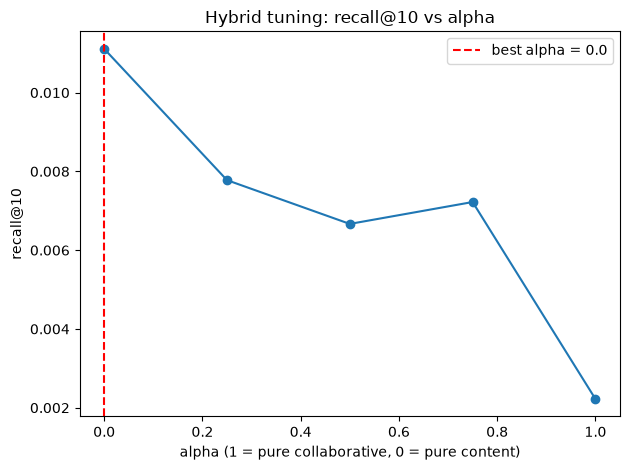

In [3]:
plt.plot(alphas, mean_recall, marker='o')
plt.axvline(best_alpha, color='red', ls='--', label=f'best alpha = {best_alpha}')
plt.xlabel('alpha (1 = pure collaborative, 0 = pure content)')
plt.ylabel('recall@10'); plt.title('Hybrid tuning: recall@10 vs alpha')
plt.legend(); plt.tight_layout(); plt.savefig('alpha_tuning.png', dpi=150); plt.show()

## 3. Statistical significance (large sample for power)

We compare per-user recall@10 of the **best model** against the **collaborative baseline** (alpha = 1)
on ~1000 users, using a paired t-test and a Wilcoxon signed-rank test. p < 0.05 means significant.

In [4]:
from scipy.stats import wilcoxon, ttest_rel

sig_users = list(rng.choice(pos_users, min(1000, len(pos_users)), replace=False))
best_fn = lambda u, it: best_alpha * cf_score(u, it) + (1 - best_alpha) * content_score(u, it)
base_fn = lambda u, it: cf_score(u, it)

rec_best = per_user_recall(best_fn, users=sig_users)
rec_base = per_user_recall(base_fn, users=sig_users)
b = np.array([rec_best[u] for u in sig_users])
a = np.array([rec_base[u] for u in sig_users])

print(f'Users tested: {len(sig_users)}')
print(f'Mean recall@10 - baseline (CF): {a.mean():.4f}')
print(f'Mean recall@10 - best model   : {b.mean():.4f}')
print(f'Mean improvement              : {(b - a).mean():+.4f}\n')

t_stat, t_p = ttest_rel(b, a)
print(f'Paired t-test:        p = {t_p:.4g}')
try:
    w_stat, w_p = wilcoxon(b, a)
    print(f'Wilcoxon signed-rank: p = {w_p:.4g}')
except ValueError as e:
    print('Wilcoxon could not run:', e)
print('\np < 0.05  =>  the best model is significantly better than the baseline.')

Users tested: 1000
Mean recall@10 - baseline (CF): 0.0006
Mean recall@10 - best model   : 0.0095
Mean improvement              : +0.0089

Paired t-test:        p = 0.001179
Wilcoxon signed-rank: p = 0.0009175

p < 0.05  =>  the best model is significantly better than the baseline.


## 4. Cold-start insight: where does the content signal help most?

Split the ~1000 users into 'cold' (few training ratings) and 'warm' (more) and compare baseline vs best.

In [5]:
train_counts = train_df['user'].value_counts()
def segment(u):
    return 'cold (<=4 ratings)' if train_counts.get(u, 0) <= 4 else 'warm (>4 ratings)'

rows = []
for seg in ['cold (<=4 ratings)', 'warm (>4 ratings)']:
    us = [u for u in sig_users if segment(u) == seg]
    if not us:
        continue
    base = np.mean([rec_base[u] for u in us])
    best = np.mean([rec_best[u] for u in us])
    rows.append((seg, len(us), round(base, 4), round(best, 4), round(best - base, 4)))
seg_df = pd.DataFrame(rows, columns=['Segment', 'Users', 'Baseline recall', 'Best-model recall', 'Gain'])
seg_df

,Segment,Users,Baseline recall,Best-model recall,Gain
0,cold (<=4 ratings),721,0.0005,0.0102,0.0097
1,warm (>4 ratings),279,0.0009,0.0077,0.0068


## 5. Summary of findings

Tuning: the best alpha found above (if 0, the optimal blend is pure content-based, meaning collaborative filtering adds little on this sparse data). Significance: the paired t-test and Wilcoxon p-values (p < 0.05 means the best model significantly beats the collaborative baseline). Cold-start: a larger gain for cold users shows the content signal helps most where collaborative filtering is weakest.